In [1]:
import torch.nn as nn
from torch.nn import functional as F

In [5]:
with open('/Users/air/Desktop/nanoGPT/data/shakespeare_char/input.txt', 'r', encoding='utf-8') as f:
    text = f.read().splitlines()

In [6]:
text

['First Citizen:',
 'Before we proceed any further, hear me speak.',
 '',
 'All:',
 'Speak, speak.',
 '',
 'First Citizen:',
 'You are all resolved rather to die than to famish?',
 '',
 'All:',
 'Resolved. resolved.',
 '',
 'First Citizen:',
 'First, you know Caius Marcius is chief enemy to the people.',
 '',
 'All:',
 "We know't, we know't.",
 '',
 'First Citizen:',
 "Let us kill him, and we'll have corn at our own price.",
 "Is't a verdict?",
 '',
 'All:',
 "No more talking on't; let it be done: away, away!",
 '',
 'Second Citizen:',
 'One word, good citizens.',
 '',
 'First Citizen:',
 'We are accounted poor citizens, the patricians good.',
 'What authority surfeits on would relieve us: if they',
 'would yield us but the superfluity, while it were',
 'wholesome, we might guess they relieved us humanely;',
 'but they think we are too dear: the leanness that',
 'afflicts us, the object of our misery, is as an',
 'inventory to particularise their abundance; our',
 'sufferance is a gain

In [23]:
chars = sorted(set(''.join(text)))
if "%" not in chars: # a stop symbol
    stoi = {s:i+1 for i, s in enumerate(chars)}
    stoi['%'] = 0
    itos = {i:s for s, i in stoi.items()}

In [45]:
import torch
N = torch.zeros((len(stoi), len(stoi)), dtype=torch.int32)

In [46]:
for w in text:
    chs = '%' + w + '%'
    for (ch1, ch2) in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [42]:
d = {}

for w in text:
    w = '%' + w + '%'
    for (ch1, ch2) in zip(w, w[1:]):
        d[ch1+ch2] = d.get(ch1+ch2, 0) + 1

In [47]:
N

tensor([[ 7223,     0,     0,  ...,     0,    66,     0],
        [    2,    16,     0,  ...,     0,  5140,    10],
        [ 1229,   879,     0,  ...,     0,     0,     0],
        ...,
        [    4,    36,     0,  ...,     0,     2,     0],
        [  396, 10283,   151,  ...,     0,     0,     0],
        [    0,     2,     1,  ...,     0,     5,    11]], dtype=torch.int32)

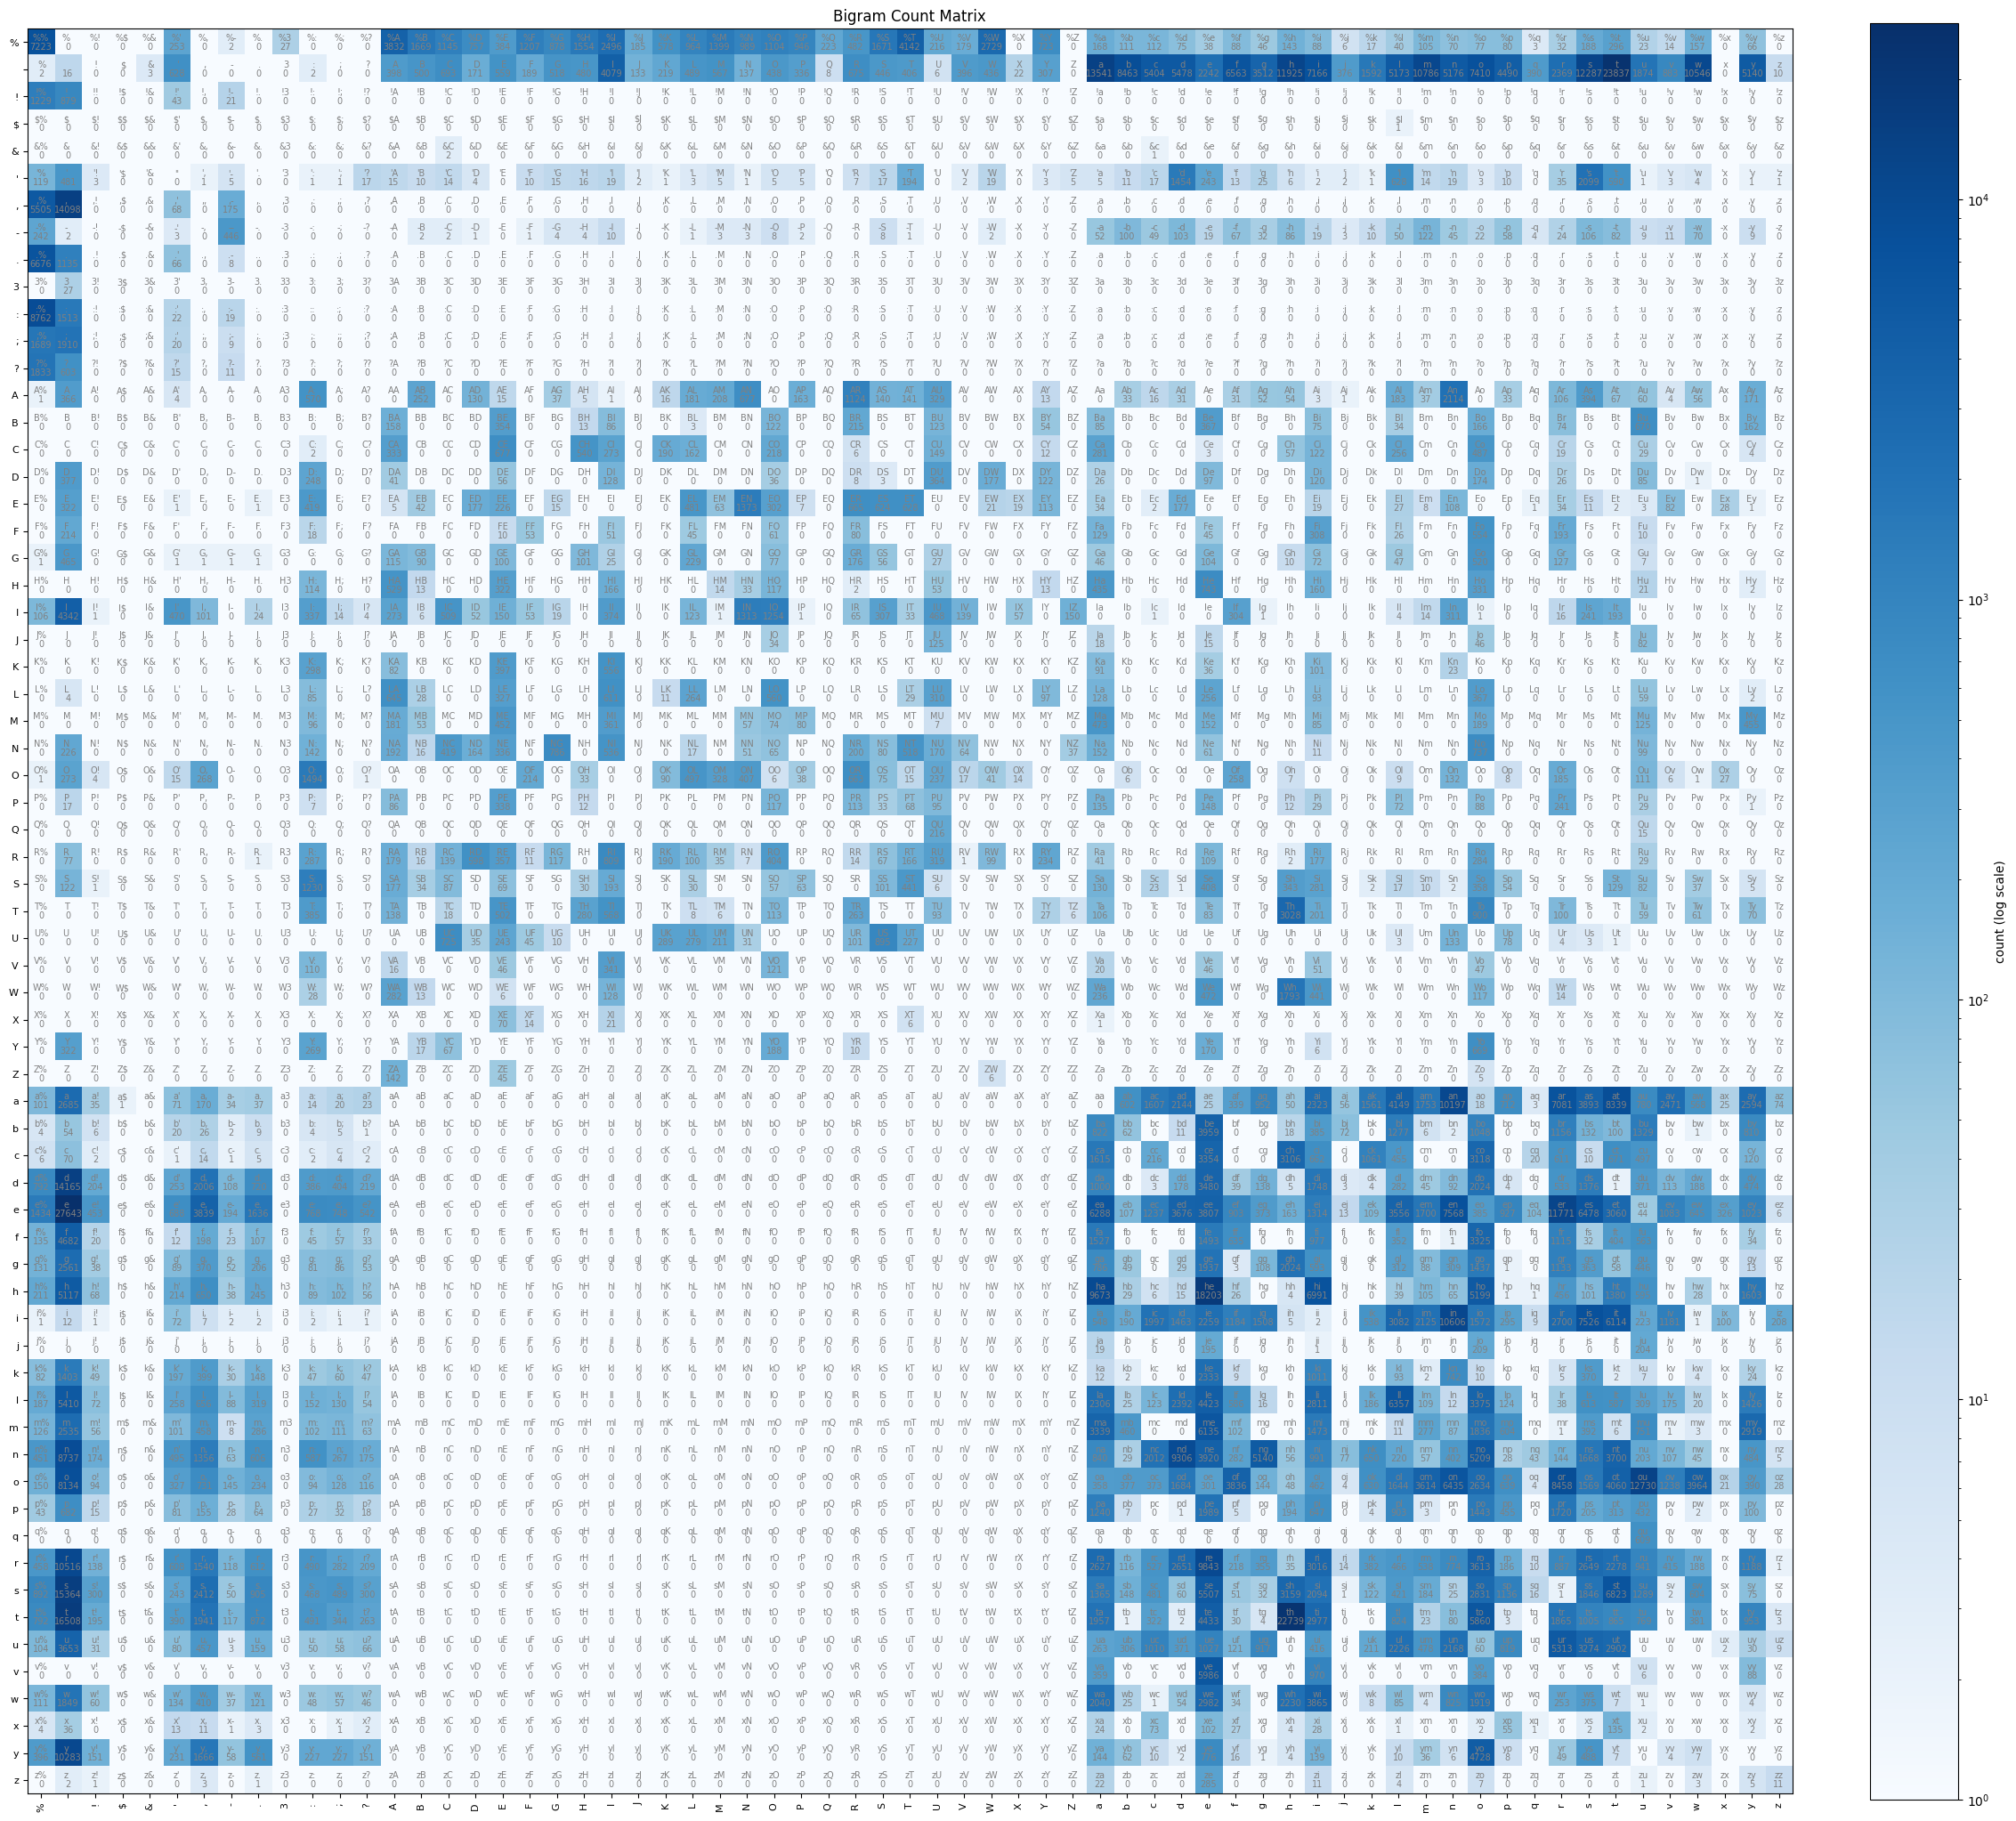

In [57]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch

V = len(stoi)
max_show = 65  # Show a readable subset when vocabulary is large.

if isinstance(N, torch.Tensor):
    N_plot = N.detach().cpu()
else:
    N_plot = N

if V > max_show:
    N_plot = N_plot[:max_show, :max_show]
    labels = [itos[i] for i in range(max_show)]
    annotate = False
    print(f'Vocabulary size={V}, showing top-left {max_show}x{max_show} block.')
else:
    labels = [itos[i] for i in range(V)]
    annotate = True

fig_size = max(8, len(labels) * 0.35)
plt.figure(figsize=(fig_size, fig_size))
plt.imshow(N_plot + 1, cmap='Blues', norm=LogNorm(vmin=1, vmax=float(N_plot.max().item() + 1)))
plt.colorbar(fraction=0.046, pad=0.04, label='count (log scale)')
plt.xticks(range(len(labels)), labels, rotation=90, fontsize=8)
plt.yticks(range(len(labels)), labels, fontsize=8)

if annotate:
    for i in range(len(labels)):
        for j in range(len(labels)):
            chstr = labels[i] + labels[j]
            chstr = chstr.replace('$', r'\$')
            plt.text(j, i, chstr, ha='center', va='bottom', color='gray', fontsize=7)
            plt.text(j, i, str(int(N_plot[i, j].item())), ha='center', va='top', color='gray', fontsize=7)

plt.title('Bigram Count Matrix')
plt.tight_layout()
plt.show()

In [58]:
P = N.float()
P/=P.sum(dim=1, keepdim=True)

In [59]:
g = torch.Generator().manual_seed(2147483647)
for row in range(6):
    out=[]
    ix = 0
    while True:
        ix = torch.multinomial(P[ix], num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))  

TICiow t thimse pr, to tor nd.%
Fiserou y denocl t, t a te fr iten!%
ISThald, g y nouthe at t, g IA:%
MICoist:%
Dilerme sus mee.%
t y irancow s on hiny,%


In [61]:
P_uniform = torch.ones(P.size())
P_uniform /= P_uniform.sum(dim=1, keepdim=True)

In [62]:
g = torch.Generator().manual_seed(2147483647)
for row in range(6):
    out=[]
    ix = 0
    while True:
        ix = torch.multinomial(P_uniform[ix], num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out)) 

TPK:&J&tDxhlit%
Dpr,rMOCtReOUf33F?HCooCSyYdKWoclkPBx IPOvX?VJfPWW&!uy3TFK3vRrTGB:X3'dzJ TYTvjwJAIemuv,C&HIAqZD,lTGmK:eux jEU$CtP Mi'WT$bpjQP OPdiWyhAC3mAKM,aYjqhW GB.mJjp.ChGNx.X&-CZ,nDqcpdf$NjmSDOVtvHYvHwjeFFaQc%
brxayMQo%
d:eWIWVsjQJIsKd.jDJTYfra -FbK&v.KS&NHU ezD?Mas!j?W.my3sTRQnDCWQfw.EARAeMEKVlw,U%
o&LnuoeQG?EH3;tdG ?ChJynXrIBiXK;,A!Twm'vvSLYHuXL$.KqAIpNpCrFht$&NcCYJ z3RDJP-.XLHhNFKYIx3bEJMK.E'?JSJmCnnV3!&.TogIh-AHVKTCsYb!XChKIDBUBymDdLHXK!ga-yXg,&YYV,cTXf:Mo;kGmFWBk:FvGaYCyP,r;et!yUT3gNunNwE&t!%
JrIYlK!qUTbvdHfuXv!If,&YGjXOE:HhRjrBS,ItESYfDOzgWhQPV?Cs&aZ?U,cSjwUwyq,znhiK%
